In [1]:
import pandas as pd

price_resid = pd.read_csv("../data/deseasonalised/price_resid.csv", index_col=0)

# Convertir l'index en datetime
price_resid.index = pd.to_datetime(price_resid.index)

# Extraire la série
price_res = price_resid["price_deseasoned"].copy()

# Rééchantillonnage en daily
price_res_daily = price_res.resample("D").mean()  # ou .ffill() selon ton besoin

# Si tu veux récupérer l'index temps
time_price_daily = price_res_daily.index

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

price_residuals = price_res_daily.copy()
price_model = ARIMA(price_residuals, order=(3,0,1))
price_result = price_model.fit()

In [7]:
price_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:       price_deseasoned   No. Observations:                 1096
Model:                 ARIMA(3, 0, 1)   Log Likelihood               -4984.222
Date:                Tue, 31 Mar 2026   AIC                           9980.443
Time:                        00:04:51   BIC                          10010.440
Sample:                    01-01-2023   HQIC                          9991.793
                         - 12-31-2025                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0259      5.366     -0.005      0.996     -10.543      10.491
ar.L1          1.5561      0.026     59.094      0.000       1.504       1.608
ar.L2         -0.6596      0.047    -14.115      0.000      -0.751      -0.568
ar.L3          0.0982      0.031      3.216      0.001       0.038       0.158
ma.L1         -0.9577      0.017    -56.177      0.000      -0.991      -0.924
sigma2       521.5763     12.320     42.337      0.000     497.430     545.722
===================================================================================
Ljung-Box (L1) (Q):                   0.08   Jarque-Bera (JB):              2224.55
Prob(Q):                              0.78   Prob(JB):                         0.00
Heteroskedasticity (H):               1.05   Skew:                             0.43
Prob(H) (two-sided):                  0.65   Kurtosis:                         9.93
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

mu_hat    = 0.001589
sigma_hat = 15.076386


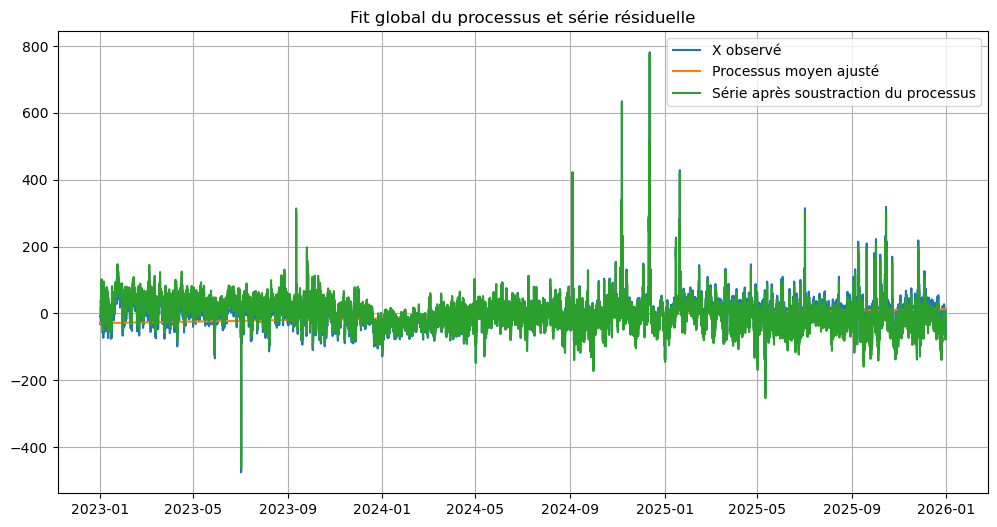

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1) Charger les données
# =========================
price_resid = pd.read_csv("../data/deseasonalised/price_resid.csv", index_col=0)
price_resid.index = pd.to_datetime(price_resid.index)

X = price_resid["price_deseasoned"].dropna().copy()
X = X.sort_index()

# =========================
# 2) Incréments du processus
#    dX_t = X_t - X_{t-1}
# =========================
dX = X.diff().dropna()

# =========================
# 3) Fit global gaussien :
#    dX_t ~ N(mu, sigma^2)
# =========================
mu_hat = dX.mean()
sigma_hat = dX.std(ddof=0)

print(f"mu_hat    = {mu_hat:.6f}")
print(f"sigma_hat = {sigma_hat:.6f}")

# =========================
# 4) Partie moyenne du processus
#    X_fit_t = X_0 + mu_hat * t
# =========================
t = np.arange(len(X))
X0 = X.iloc[0]

X_fit = pd.Series(
    X0 + mu_hat * t,
    index=X.index,
    name="X_fit"
)

# =========================
# 5) Série résiduelle :
#    on enlève le processus moyen
# =========================
X_residual = (X - X_fit).rename("price_deseasoned_residual")
X_residual = X_residual - X_residual.mean()

# =========================
# 6) DataFrame final, comme avant
# =========================
price_resid_new = pd.DataFrame(index=X.index)
price_resid_new["price_deseasoned_residual"] = X_residual

# =========================
# 7) Graphique utile uniquement
# =========================
plt.figure(figsize=(12, 6))
plt.plot(X.index, X.values, label="X observé")
plt.plot(X_fit.index, X_fit.values, label="Processus moyen ajusté")
plt.plot(X_residual.index, X_residual.values, label="Série après soustraction du processus")
plt.legend()
plt.grid(True)
plt.title("Fit global du processus et série résiduelle")
plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

price_residuals = price_resid_new.copy()
price_model = ARIMA(price_residuals, order=(3,0,1))
price_result = price_model.fit()

c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\gabri\miniforge3\envs\carma\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [9]:
price_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                   SARIMAX Results                                   
=====================================================================================
Dep. Variable:     price_deseasoned_residual   No. Observations:                26281
Model:                        ARIMA(3, 0, 1)   Log Likelihood             -106889.795
Date:                       Mon, 30 Mar 2026   AIC                         213791.589
Time:                               12:26:04   BIC                         213840.649
Sample:                           01-01-2023   HQIC                        213807.430
                                - 12-31-2025                                         
Covariance Type:                         opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0011      2.451     -0.000      1.000      -4.805       4.803
ar.L1          2.0594      0.004    488.744      0.000       2.051       2.068
ar.L2         -1.3589      0.005   -265.933      0.000      -1.369      -1.349
ar.L3          0.2960      0.002    155.979      0.000       0.292       0.300
ma.L1         -0.9089      0.004   -215.561      0.000      -0.917      -0.901
sigma2       199.6220      0.371    537.455      0.000     198.894     200.350
===================================================================================
Ljung-Box (L1) (Q):                   6.48   Jarque-Bera (JB):           4178280.50
Prob(Q):                              0.01   Prob(JB):                         0.00
Heteroskedasticity (H):               1.95   Skew:                             1.34
Prob(H) (two-sided):                  0.00   Kurtosis:                        64.71
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""